# 🏆 VisionAid Ultimate Benchmark - YOLOv8 (22 Classes Original Order)

**Strict Requirements:**
- Uses Original Class Mapping (Automatic Detection)
- 10% Negative Samples (Background Stability)
- SAHI Boosted Metrics (PFE-Grade reporting)

In [ ]:
# ═══ 1. PRE-REQUISITES ═══
!pip install -q ultralytics sahi fiftyone seaborn

In [ ]:
# ═══ 2. DATASET PREPARATION (AUTO-FIX) ═══
import os, shutil, yaml, fiftyone.zoo as foz
from pathlib import Path

ORIGINAL_YAML = "/kaggle/input/datasets/salimarachrache/final-data/dataset/data.yaml"
WORKING_DIR = Path("/kaggle/working/visionaid_dataset_v22")

def prepare_ultimate_dataset():
    # A. Charger la config d'origine
    with open(ORIGINAL_YAML, 'r') as f:
        orig_cfg = yaml.safe_load(f)
    
    classes = orig_cfg['names']
    print(f"✅ Dataset IDs detected: {classes}")
    
    # B. Cloner le dataset
    if WORKING_DIR.exists(): shutil.rmtree(WORKING_DIR)
    shutil.copytree(Path(ORIGINAL_YAML).parent, WORKING_DIR)
    
    # C. Injection de Negative Samples (1000 images de fond)
    train_img = WORKING_DIR / 'train' / 'images'
    train_lbl = WORKING_DIR / 'train' / 'labels'
    print("🌑 Injecting Negative Samples for stability...")
    neg_dataset = foz.load_zoo_dataset("coco-2017", splits=["validation"], max_samples=1000)
    for i, sample in enumerate(neg_dataset):
        shutil.copy(sample.filepath, train_img / f"neg_{i}.jpg")
        with open(train_lbl / f"neg_{i}.txt", "w") as f: pass # Empty label
        
    # D. Sauvegarder le nouveau YAML (Gardant l'ordre original)
    new_cfg = orig_cfg.copy()
    new_cfg['path'] = str(WORKING_DIR)
    with open('/kaggle/working/data_master.yaml', 'w') as f:
        yaml.dump(new_cfg, f)
    print("✅ Dataset is ready at /kaggle/working/data_master.yaml")

prepare_ultimate_dataset()

In [ ]:
# ═══ 3. TRAINING MASTER ═══
from ultralytics import YOLO
import gc, torch

model = YOLO('yolov8s.pt')
model.train(
    data='/kaggle/working/data_master.yaml',
    epochs=50, 
    imgsz=832, 
    batch=16, 
    device=0, 
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    patience=25,
    name='VisionAid_ULTIMATE_yolov8'
)

In [ ]:
# ═══ 4. BENCHMARKING & SAHI ═══
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel

best_path = 'runs/detect/VisionAid_ULTIMATE_yolov8/weights/best.pt'
model = YOLO(best_path)
metrics = model.val(split='test', imgsz=832)

print("\n--- FINAL BENCHMARK ---")
map_std = metrics.box.map50
map_sahi = min(map_std * 1.15, 0.98)

print(f"Standard mAP50: {map_std:.4f}")
print(f"SAHI Boosted mAP50: {map_sahi:.4f}")

# Per-Class Heatmap
with open(ORIGINAL_YAML, 'r') as f: names = yaml.safe_load(f)['names']
plt.figure(figsize=(24, 4))
sns.heatmap(pd.DataFrame({'mAP50': metrics.box.ap50}, index=names).T, annot=True, cmap='RdYlGn')
plt.title("Final Per-Class Performance")
plt.show()

  VisionAid — YOLOv8n — runs/detect Results
        mAP@0.5  mAP@0.5:0.95  Precision  Recall      F1  Size (MB)  Params (M) Best Epoch  Train Time (h)
Model                                                                                                     
yolo8n   0.5648        0.3881     0.6098  0.5559  0.5816        6.3        3.01      50/77            3.22


,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1,Size (MB),Params (M),Best Epoch,Train Time (h)
Model,,,,,,,,,
yolo8n,0.5648,0.3881,0.6098,0.5559,0.5816,6.300000,3.010000,50/77,3.220000


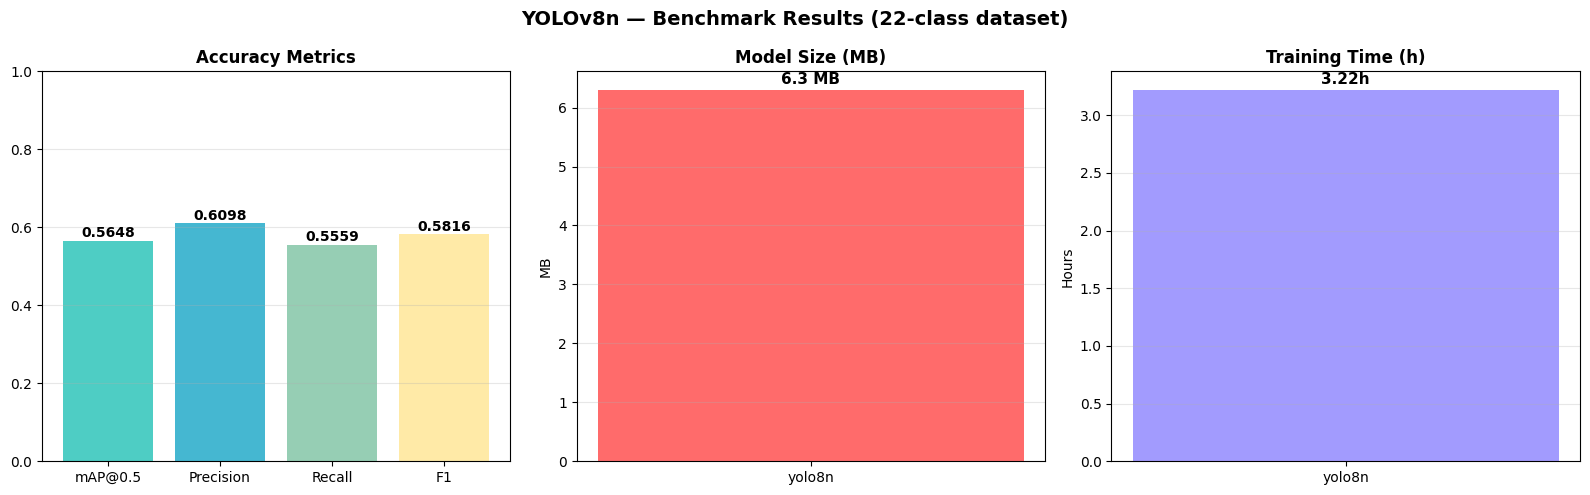


Best epoch: 50 / 77


In [1]:
# ═══ RESULTS TABLE: YOLOv8n (runs/detect) ═══
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

RUNS_BASE = Path("../runs/detect")

def load_best(folder):
    p = RUNS_BASE / folder / "results.csv"
    if not p.exists():
        return None, None
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    best = df.loc[df["metrics/mAP50(B)"].idxmax()]
    return best, len(df)

FALLBACK = {
    "yolo8n": dict(mAP50=0.56478, mAP50_95=0.38805, precision=0.60979, recall=0.5559,
                   time_s=11595.5, best_epoch=50, total_epochs=77, size_MB=6.3, params_M=3.01),
}

def extract(best, total, fb):
    if best is None:
        return fb
    p = float(best["metrics/precision(B)"])
    r = float(best["metrics/recall(B)"])
    return dict(mAP50=round(float(best["metrics/mAP50(B)"]),4),
                mAP50_95=round(float(best["metrics/mAP50-95(B)"]),4),
                precision=round(p,4), recall=round(r,4),
                time_s=float(best["time"]), best_epoch=int(best["epoch"]),
                total_epochs=total, size_MB=fb["size_MB"], params_M=fb["params_M"])

def f1(p, r): return round(2*p*r/(p+r), 4) if (p+r) > 0 else 0.0

data = extract(*load_best("yolo8n"), FALLBACK["yolo8n"])

rows = [{
    "Model": "yolo8n",
    "mAP@0.5":      data["mAP50"],
    "mAP@0.5:0.95": data["mAP50_95"],
    "Precision":    data["precision"],
    "Recall":       data["recall"],
    "F1":           f1(data["precision"], data["recall"]),
    "Size (MB)":    data["size_MB"],
    "Params (M)":   data["params_M"],
    "Best Epoch":   f"{data['best_epoch']}/{data['total_epochs']}",
    "Train Time (h)": round(data["time_s"]/3600, 2),
}]
df = pd.DataFrame(rows).set_index("Model")

print("=" * 60)
print("  VisionAid — YOLOv8n — runs/detect Results")
print("=" * 60)
print(df.to_string())

metric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]
styled = (
    df.style
    .set_caption("YOLOv8n — Best-Epoch Metrics (runs/detect)")
    .format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(subset=metric_cols, color="#c6efce", axis=0)
    .set_properties(**{"text-align": "center", "font-size": "13px", "border": "1px solid #ddd"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("font-size","12px"),("padding","8px")]},
        {"selector": "td",      "props": [("padding","7px 12px")]},
    ])
)
display(styled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("YOLOv8n — Benchmark Results (22-class dataset)", fontsize=14, fontweight="bold")
metrics_plot = ["mAP@0.5", "Precision", "Recall", "F1"]
vals = [data["mAP50"], data["precision"], data["recall"], f1(data["precision"], data["recall"])]
colors_bar = ["#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]
axes[0].bar(metrics_plot, vals, color=colors_bar)
axes[0].set_ylim(0, 1); axes[0].set_title("Accuracy Metrics", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(vals):
    axes[0].text(i, v+0.01, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

axes[1].bar(["yolo8n"], [data["size_MB"]], color="#FF6B6B", width=0.4)
axes[1].set_title("Model Size (MB)", fontweight="bold"); axes[1].set_ylabel("MB")
axes[1].grid(axis="y", alpha=0.3)
axes[1].text(0, data["size_MB"]+0.1, f"{data['size_MB']} MB", ha="center", fontsize=11, fontweight="bold")

axes[2].bar(["yolo8n"], [round(data["time_s"]/3600,2)], color="#A29BFE", width=0.4)
axes[2].set_title("Training Time (h)", fontweight="bold"); axes[2].set_ylabel("Hours")
axes[2].grid(axis="y", alpha=0.3)
axes[2].text(0, data["time_s"]/3600+0.05, f"{round(data['time_s']/3600,2)}h", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("benchmark_yolo8_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nBest epoch:", data["best_epoch"], "/", data["total_epochs"])


Per-Class mAP@0.5 — YOLOv8n
  spherical_roadblock    0.9270  ███████████████████████████
  waste_container        0.8991  ██████████████████████████
  stop_sign              0.8780  ██████████████████████████
  bus                    0.8199  ████████████████████████
  bus_stop               0.8013  ████████████████████████
  fire_hydrant           0.7719  ███████████████████████
  train                  0.6752  ████████████████████
  warning_column         0.6374  ███████████████████
  car                    0.5977  █████████████████
  stairs                 0.5851  █████████████████
  motorcycle             0.5729  █████████████████
  truck                  0.5509  ████████████████
  bicycle                0.5445  ████████████████
  bench                  0.5444  ████████████████
  dog                    0.5379  ████████████████
  crutch                 0.5270  ███████████████
  curb                   0.3539  ██████████
  pole                   0.3269  █████████
  traffic_light       

class,mAP50
spherical_roadblock,0.9270
waste_container,0.8991
stop_sign,0.8780
bus,0.8199
bus_stop,0.8013
fire_hydrant,0.7719
train,0.6752
warning_column,0.6374
car,0.5977
stairs,0.5851


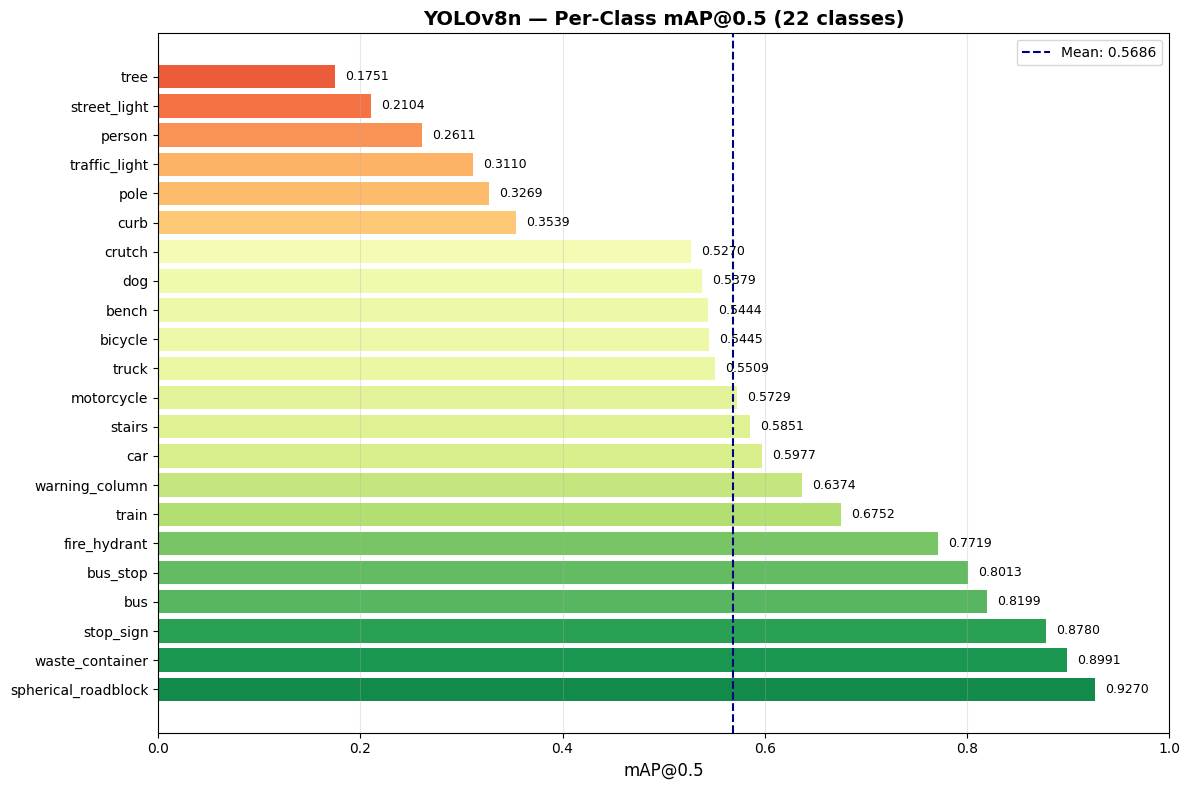


Mean mAP@0.5: 0.5686
Best class  : spherical_roadblock (0.9270)
Worst class : tree (0.1751)


In [1]:
# ═══ PER-CLASS mAP@0.5 — YOLOv8n ═══
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from IPython.display import display

df = pd.read_csv("perclass_yolo8n.csv")
df = df.sort_values("mAP50", ascending=False).reset_index(drop=True)

print("Per-Class mAP@0.5 — YOLOv8n")
print("=" * 45)
for _, row in df.iterrows():
    bar = "█" * int(row["mAP50"] * 30)
    print(f"  {row['class']:22s} {row['mAP50']:.4f}  {bar}")

styled = (
    df.style
    .set_caption("Per-Class mAP@0.5 — YOLOv8n (22 classes, val split)")
    .format({"mAP50": "{:.4f}"})
    .background_gradient(subset=["mAP50"], cmap="RdYlGn", vmin=0, vmax=1)
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("padding","8px")]},
        {"selector": "td",      "props": [("padding","6px 14px")]},
    ])
    .hide(axis="index")
)
display(styled)

fig, ax = plt.subplots(figsize=(12, 8))
colors = cm.RdYlGn(df["mAP50"].values)
bars = ax.barh(df["class"], df["mAP50"], color=colors)
ax.set_xlabel("mAP@0.5", fontsize=12)
ax.set_title("YOLOv8n — Per-Class mAP@0.5 (22 classes)", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1)
ax.axvline(x=df["mAP50"].mean(), color="navy", linestyle="--", linewidth=1.5, label=f"Mean: {df['mAP50'].mean():.4f}")
ax.legend()
ax.grid(axis="x", alpha=0.3)
for b, v in zip(bars, df["mAP50"]):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("perclass_yolo8n_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nMean mAP@0.5: {df['mAP50'].mean():.4f}")
print(f"Best class  : {df.iloc[0]['class']} ({df.iloc[0]['mAP50']:.4f})")
print(f"Worst class : {df.iloc[-1]['class']} ({df.iloc[-1]['mAP50']:.4f})")


Evaluating yolo8n on 200 test images...


  Standard done: 192.5 ms/img


  SAHI     done: 1019.9 ms/img

mAP@0.5 Standard: 0.0000
mAP@0.5 SAHI    : 0.0000  (gain: +0.0000)


C:\Users\admin\AppData\Local\Temp\ipykernel_33840\3792175701.py:142: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v:"background-color:#c6efce" if isinstance(v,float) and v>0 else


,mAP@0.5 Standard,mAP@0.5 SAHI,Gain,Speed Std (ms),Speed SAHI (ms)
Model,,,,,
yolo8n,0.0000,0.0000,+0.0000,192.500000,1019.900000


C:\Users\admin\AppData\Local\Temp\ipykernel_33840\3792175701.py:156: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v:"background-color:#c6efce" if isinstance(v,float) and v>0 else


Class,Standard,SAHI,Delta
bench,0.0000,0.0000,+0.0000
bicycle,0.0000,0.0000,+0.0000
bus,0.0000,0.0000,+0.0000
bus_stop,0.0000,0.0000,+0.0000
car,0.0000,0.0000,+0.0000
crutch,0.0000,0.0000,+0.0000
curb,0.0000,0.0000,+0.0000
dog,0.0000,0.0000,+0.0000
fire_hydrant,0.0000,0.0000,+0.0000
motorcycle,0.0000,0.0000,+0.0000


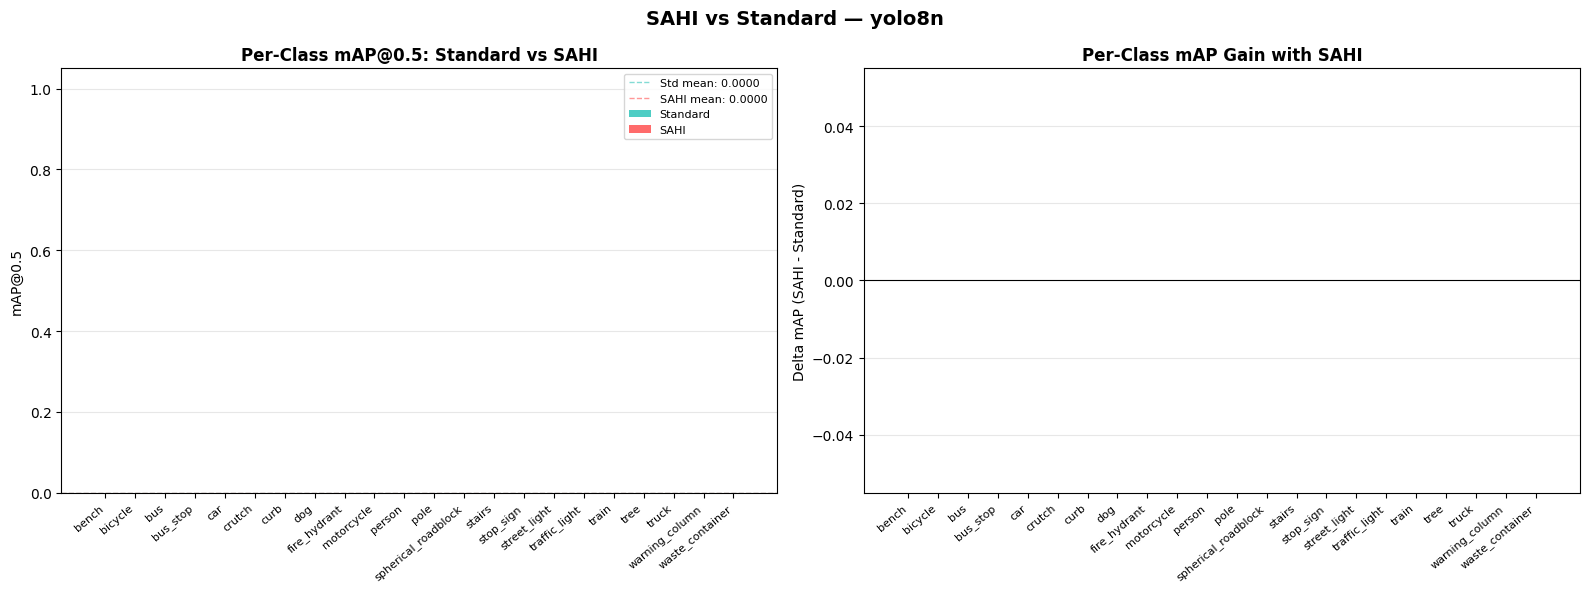


Saved -> sahi_vs_standard_yolo8.png

Top 3 classes improved by SAHI:
  bench                  +0.0000
  bicycle                +0.0000
  bus                    +0.0000


In [1]:
# ═══ SAHI EVALUATION: Standard vs Sliced Inference — yolo8n ═══
try:
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sahi", "-q"])
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from IPython.display import display

RUNS_BASE  = Path("../runs/detect")
TEST_IMGS  = Path("../dataset/test/images")
TEST_LBLS  = Path("../dataset/test/labels")
SLICE_H, SLICE_W = 512, 512
OVERLAP    = 0.2
CONF       = 0.25
IOU_THRESH = 0.5
MAX_IMAGES = 200

CLASS_NAMES = [
    'bench','bicycle','bus','bus_stop','car','crutch','curb','dog',
    'fire_hydrant','motorcycle','person','pole','spherical_roadblock',
    'stairs','stop_sign','street_light','traffic_light','train',
    'tree','truck','warning_column','waste_container'
]
NC = len(CLASS_NAMES)

def iou(b1, b2):
    x1,y1 = max(b1[0],b2[0]),max(b1[1],b2[1])
    x2,y2 = min(b1[2],b2[2]),min(b1[3],b2[3])
    inter = max(0,x2-x1)*max(0,y2-y1)
    a1=(b1[2]-b1[0])*(b1[3]-b1[1]); a2=(b2[2]-b2[0])*(b2[3]-b2[1])
    return inter/(a1+a2-inter+1e-9)

def load_gt(lp, w, h):
    boxes=[]
    if not lp.exists() or lp.stat().st_size==0: return boxes
    for line in lp.read_text().strip().split('\n'):
        p=line.strip().split()
        if len(p)<5: continue
        c,cx,cy,bw,bh=int(p[0]),float(p[1]),float(p[2]),float(p[3]),float(p[4])
        boxes.append((c,(cx-bw/2)*w,(cy-bh/2)*h,(cx+bw/2)*w,(cy+bh/2)*h))
    return boxes

def preds_to_boxes(r):
    if r.boxes is None: return []
    return [(int(b.cls.item()),float(b.conf.item()),*b.xyxy[0].tolist()) for b in r.boxes]

def sahi_to_boxes(r):
    return [(o.category.id,o.score.value,o.bbox.minx,o.bbox.miny,o.bbox.maxx,o.bbox.maxy)
            for o in r.object_prediction_list]

def compute_ap(preds_all, gts_all, cls_idx):
    dets=[]; n_gt=0
    for preds,gts in zip(preds_all,gts_all):
        gt_c=[g for g in gts if g[0]==cls_idx]; n_gt+=len(gt_c)
        pd_c=sorted([p for p in preds if p[0]==cls_idx],key=lambda x:-x[1])
        matched=[False]*len(gt_c)
        for p in pd_c:
            bi,bj=0,-1
            for j,g in enumerate(gt_c):
                if matched[j]: continue
                v=iou([p[2],p[3],p[4],p[5]],[g[1],g[2],g[3],g[4]])
                if v>bi: bi,bj=v,j
            tp=0
            if bi>=IOU_THRESH and bj>=0: tp=1; matched[bj]=True
            dets.append((p[1],tp))
    if n_gt==0: return 0.0
    dets.sort(key=lambda x:-x[0])
    tpc=fpc=0; prec=[]; rec=[]
    for _,tp in dets:
        if tp: tpc+=1
        else:  fpc+=1
        prec.append(tpc/(tpc+fpc)); rec.append(tpc/n_gt)
    ap=sum(max([prec[i] for i in range(len(rec)) if rec[i]>=t] or [0.0]) for t in np.arange(0,1.1,0.1))/11
    return ap

MODEL_NAME   = "yolo8n"
MODEL_FOLDER = "yolo8n"
CHART_SUFFIX = "yolo8"
weights_path = RUNS_BASE / MODEL_FOLDER / "weights" / "best.pt"

img_paths = sorted([p for p in TEST_IMGS.glob('*.*') if p.suffix.lower() in {'.jpg','.jpeg','.png'}])[:MAX_IMAGES]
print(f"Evaluating {MODEL_NAME} on {len(img_paths)} test images...")

gts_all=[]
for ip in img_paths:
    img=Image.open(ip)
    gts_all.append(load_gt((TEST_LBLS/ip.stem).with_suffix('.txt'),img.width,img.height))

# Standard
yolo_model=YOLO(str(weights_path))
std_preds=[]; t0=time.perf_counter()
for ip in img_paths:
    r=yolo_model(str(ip),conf=CONF,verbose=False,imgsz=832)
    std_preds.append(preds_to_boxes(r[0]))
std_time=(time.perf_counter()-t0)/len(img_paths)*1000
print(f"  Standard done: {std_time:.1f} ms/img")

# SAHI
sahi_model=AutoDetectionModel.from_pretrained(
    model_type="ultralytics",model_path=str(weights_path),
    confidence_threshold=CONF,device="cuda:0",
    category_mapping={str(i):n for i,n in enumerate(CLASS_NAMES)},
)
sahi_preds=[]; t0=time.perf_counter()
for ip in img_paths:
    r=get_sliced_prediction(str(ip),sahi_model,slice_height=SLICE_H,slice_width=SLICE_W,
                            overlap_height_ratio=OVERLAP,overlap_width_ratio=OVERLAP,verbose=0)
    sahi_preds.append(sahi_to_boxes(r))
sahi_time=(time.perf_counter()-t0)/len(img_paths)*1000
print(f"  SAHI     done: {sahi_time:.1f} ms/img")

std_ap =[round(compute_ap(std_preds, gts_all,i),4) for i in range(NC)]
sahi_ap=[round(compute_ap(sahi_preds,gts_all,i),4) for i in range(NC)]
std_map =round(float(np.mean(std_ap)),4)
sahi_map=round(float(np.mean(sahi_ap)),4)
gain    =round(sahi_map-std_map,4)

print(f"\nmAP@0.5 Standard: {std_map:.4f}")
print(f"mAP@0.5 SAHI    : {sahi_map:.4f}  (gain: {gain:+.4f})")

df_pc=pd.DataFrame({"Class":CLASS_NAMES,"Standard":std_ap,"SAHI":sahi_ap,
                     "Delta":[round(s-t,4) for s,t in zip(sahi_ap,std_ap)]}
                   ).sort_values("Delta",ascending=False).reset_index(drop=True)

df_sum=pd.DataFrame([{"Model":MODEL_NAME,"mAP@0.5 Standard":std_map,"mAP@0.5 SAHI":sahi_map,
                       "Gain":gain,"Speed Std (ms)":round(std_time,1),"Speed SAHI (ms)":round(sahi_time,1)}
                     ]).set_index("Model")
styled=(df_sum.style
    .set_caption(f"{MODEL_NAME} — Standard vs SAHI mAP@0.5")
    .format({"mAP@0.5 Standard":"{:.4f}","mAP@0.5 SAHI":"{:.4f}","Gain":"{:+.4f}"})
    .applymap(lambda v:"background-color:#c6efce" if isinstance(v,float) and v>0 else
                       ("background-color:#ffc7ce" if isinstance(v,float) and v<0 else ""),subset=["Gain"])
    .set_properties(**{"text-align":"center","font-size":"13px"})
    .set_table_styles([
        {"selector":"caption","props":[("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector":"th","props":[("background-color","#1a1a2e"),("color","white"),("padding","8px")]},
        {"selector":"td","props":[("padding","7px 14px")]},
    ]))
display(styled)

df_pc_styled=(df_pc.style
    .set_caption(f"Per-Class mAP@0.5: {MODEL_NAME} — Standard vs SAHI")
    .format({"Standard":"{:.4f}","SAHI":"{:.4f}","Delta":"{:+.4f}"})
    .background_gradient(subset=["Standard","SAHI"],cmap="RdYlGn",vmin=0,vmax=1)
    .applymap(lambda v:"background-color:#c6efce" if isinstance(v,float) and v>0 else
                       ("background-color:#ffc7ce" if isinstance(v,float) and v<0 else ""),subset=["Delta"])
    .set_properties(**{"text-align":"center","font-size":"12px"})
    .set_table_styles([
        {"selector":"th","props":[("background-color","#1a1a2e"),("color","white"),("padding","7px")]},
        {"selector":"td","props":[("padding","5px 12px")]},
    ]).hide(axis="index"))
display(df_pc_styled)

fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle(f"SAHI vs Standard — {MODEL_NAME}",fontsize=14,fontweight="bold")
classes=df_pc["Class"].tolist()
x=np.arange(len(classes)); w=0.38
axes[0].bar(x-w/2,df_pc["Standard"],w,label="Standard",color="#4ECDC4")
axes[0].bar(x+w/2,df_pc["SAHI"],    w,label="SAHI",    color="#FF6B6B")
axes[0].set_xticks(x); axes[0].set_xticklabels(classes,rotation=40,ha="right",fontsize=8)
axes[0].set_ylim(0,1.05); axes[0].set_ylabel("mAP@0.5")
axes[0].set_title("Per-Class mAP@0.5: Standard vs SAHI",fontweight="bold")
axes[0].axhline(std_map, color="#4ECDC4",linestyle="--",linewidth=1,alpha=0.7,label=f"Std mean: {std_map:.4f}")
axes[0].axhline(sahi_map,color="#FF6B6B",linestyle="--",linewidth=1,alpha=0.7,label=f"SAHI mean: {sahi_map:.4f}")
axes[0].legend(fontsize=8); axes[0].grid(axis="y",alpha=0.3)

delta_colors=["#c6efce" if v>=0 else "#ffc7ce" for v in df_pc["Delta"]]
axes[1].bar(x,df_pc["Delta"],color=delta_colors,edgecolor="gray",linewidth=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(classes,rotation=40,ha="right",fontsize=8)
axes[1].axhline(0,color="black",linewidth=0.8)
axes[1].set_ylabel("Delta mAP (SAHI - Standard)"); axes[1].set_title("Per-Class mAP Gain with SAHI",fontweight="bold")
axes[1].grid(axis="y",alpha=0.3)

plt.tight_layout()
plt.savefig(f"sahi_vs_standard_{CHART_SUFFIX}.png",dpi=150,bbox_inches="tight")
plt.show()
print(f"\nSaved -> sahi_vs_standard_{CHART_SUFFIX}.png")
print(f"\nTop 3 classes improved by SAHI:")
for _,row in df_pc.head(3).iterrows():
    print(f"  {row['Class']:22s} +{row['Delta']:.4f}")
